In [1]:
import pickle
import pandas as pd
import numpy as np
from pathlib import Path
import random
import matplotlib.pyplot as plt

Dataset = 'HUST'

data_folder = Path("Battery_life_Dataset/",Dataset)

pkl_files = list(data_folder.glob("*.pkl"))
selected_files = pkl_files  # Use all files for now, you can uncomment the next line to select a random sample
# selected_files = random.sample(pkl_files, 100)

datasets = []

for pkl_file in selected_files:
    with open(pkl_file, "rb") as f:
        datasets.append(pickle.load(f))

print([d["cell_id"] for d in datasets])

['HUST_1-1', 'HUST_1-2', 'HUST_1-3', 'HUST_1-4', 'HUST_1-5', 'HUST_1-6', 'HUST_1-7', 'HUST_1-8', 'HUST_10-1', 'HUST_10-2', 'HUST_10-3', 'HUST_10-4', 'HUST_10-5', 'HUST_10-6', 'HUST_10-7', 'HUST_10-8', 'HUST_2-2', 'HUST_2-3', 'HUST_2-4', 'HUST_2-5', 'HUST_2-6', 'HUST_2-7', 'HUST_2-8', 'HUST_3-1', 'HUST_3-2', 'HUST_3-3', 'HUST_3-4', 'HUST_3-5', 'HUST_3-6', 'HUST_3-7', 'HUST_3-8', 'HUST_4-1', 'HUST_4-2', 'HUST_4-3', 'HUST_4-4', 'HUST_4-5', 'HUST_4-6', 'HUST_4-7', 'HUST_4-8', 'HUST_5-1', 'HUST_5-2', 'HUST_5-3', 'HUST_5-4', 'HUST_5-5', 'HUST_5-6', 'HUST_5-7', 'HUST_6-1', 'HUST_6-2', 'HUST_6-3', 'HUST_6-4', 'HUST_6-5', 'HUST_6-6', 'HUST_6-8', 'HUST_7-1', 'HUST_7-2', 'HUST_7-3', 'HUST_7-4', 'HUST_7-5', 'HUST_7-6', 'HUST_7-7', 'HUST_7-8', 'HUST_8-1', 'HUST_8-2', 'HUST_8-3', 'HUST_8-4', 'HUST_8-5', 'HUST_8-6', 'HUST_8-7', 'HUST_8-8', 'HUST_9-1', 'HUST_9-2', 'HUST_9-3', 'HUST_9-4', 'HUST_9-5', 'HUST_9-6', 'HUST_9-7', 'HUST_9-8']


In [2]:
# Display key in the datasets

print(datasets[0].keys())
for key, value in datasets[0].items():
    print(key, type(value))

dict_keys(['cell_id', 'cycle_data', 'form_factor', 'anode_material', 'cathode_material', 'electrolyte_material', 'nominal_capacity_in_Ah', 'depth_of_charge', 'depth_of_discharge', 'already_spent_cycles', 'max_voltage_limit_in_V', 'min_voltage_limit_in_V', 'max_current_limit_in_A', 'min_current_limit_in_A', 'reference', 'description', 'charge_protocol', 'discharge_protocol', 'SOC_interval'])
cell_id <class 'str'>
cycle_data <class 'list'>
form_factor <class 'str'>
anode_material <class 'str'>
cathode_material <class 'str'>
electrolyte_material <class 'NoneType'>
nominal_capacity_in_Ah <class 'float'>
depth_of_charge <class 'float'>
depth_of_discharge <class 'float'>
already_spent_cycles <class 'int'>
max_voltage_limit_in_V <class 'float'>
min_voltage_limit_in_V <class 'float'>
max_current_limit_in_A <class 'NoneType'>
min_current_limit_in_A <class 'NoneType'>
reference <class 'NoneType'>
description <class 'NoneType'>
charge_protocol <class 'list'>
discharge_protocol <class 'list'>
SOC_

In [3]:
# Selection of which cycles to keep in the dataset

step = 20
keep_cycles = [5,10,15,30]

def reduce_cycles(cycle_data, step=20, keep_cycles=[5, 10, 15, 30]):

    """ 
    Reduces the number of cycles in the dataset based on the specified step size.
    
    Arguments:
    cycle_data -- List of dictionaries containing cycle data.
    step -- Step size for selecting cycles (default is 20). 
    keep_cycles -- List of specific cycle numbers to keep (default is [5, 10, 15, 30]).

    Returns:
    A filtered list of cycle data dictionaries, keeping cycles based on the specified step size.

    The function retains cycles with cycle numbers less than or equal to 5, as well 
    as cycles within keep_cycles. Additionally, it keeps cycles whose cycle numbers are multiples of the specified step size.

    """
    return [
        cycle
        for cycle in cycle_data
        if cycle["cycle_number"] <= 5
        or cycle["cycle_number"] in keep_cycles
        or cycle["cycle_number"] % step == 0
    ]

for dataset in datasets:
    dataset["cycle_data"] = reduce_cycles(dataset["cycle_data"], step=20)

In [4]:
# Display the number of cycles in each dataset and the first 10 cycle numbers

for dataset in datasets:
    print(
        dataset["cell_id"],
        len(dataset["cycle_data"]),
        [c["cycle_number"] for c in dataset["cycle_data"][:10]]
    )

HUST_1-1 83 [1, 2, 3, 4, 5, 10, 15, 20, 30, 40]
HUST_1-2 141 [1, 2, 3, 4, 5, 10, 15, 20, 30, 40]
HUST_1-3 100 [1, 2, 3, 4, 5, 10, 15, 20, 30, 40]
HUST_1-4 83 [1, 2, 3, 4, 5, 10, 15, 20, 30, 40]
HUST_1-5 106 [1, 2, 3, 4, 5, 10, 15, 20, 30, 40]
HUST_1-6 65 [1, 2, 3, 4, 5, 10, 15, 20, 30, 40]
HUST_1-7 91 [1, 2, 3, 4, 5, 10, 15, 20, 30, 40]
HUST_1-8 122 [1, 2, 3, 4, 5, 10, 15, 20, 30, 40]
HUST_10-1 93 [1, 2, 3, 4, 5, 10, 15, 20, 30, 40]
HUST_10-2 92 [1, 2, 3, 4, 5, 10, 15, 20, 30, 40]
HUST_10-3 100 [1, 2, 3, 4, 5, 10, 15, 20, 30, 40]
HUST_10-4 98 [1, 2, 3, 4, 5, 10, 15, 20, 30, 40]
HUST_10-5 109 [1, 2, 3, 4, 5, 10, 15, 20, 30, 40]
HUST_10-6 122 [1, 2, 3, 4, 5, 10, 15, 20, 30, 40]
HUST_10-7 97 [1, 2, 3, 4, 5, 10, 15, 20, 30, 40]
HUST_10-8 78 [1, 2, 3, 4, 5, 10, 15, 20, 30, 40]
HUST_2-2 140 [1, 2, 3, 4, 5, 10, 15, 20, 30, 40]
HUST_2-3 95 [1, 2, 3, 4, 5, 10, 15, 20, 30, 40]
HUST_2-4 82 [1, 2, 3, 4, 5, 10, 15, 20, 30, 40]
HUST_2-5 77 [1, 2, 3, 4, 5, 10, 15, 20, 30, 40]
HUST_2-6 86 [1, 2, 3, 4,

In [5]:
# Feature-Engineering: Berechnung von SOH, Strom- und Spannungsstatistiken sowie Lade-/Entladezeiten

features = []

for data in datasets:

    cycles = data["cycle_data"]

    Q0 = np.max(cycles[1]["discharge_capacity_in_Ah"])

    for cycle in cycles:

        I = np.array(cycle["current_in_A"], dtype=np.float32)
        V = np.array(cycle["voltage_in_V"], dtype=np.float32)
        t = np.array(cycle["time_in_s"], dtype=np.float32)

        # SOH
        Q_discharge = np.max(cycle["discharge_capacity_in_Ah"])
        soh = Q_discharge / Q0

        # Zeitdifferenzen
        dt = np.diff(t, prepend=t[0])

        charge_duration = np.sum(dt[I > 0])
        discharge_duration = np.sum(dt[I < 0])

        features.append({
            "cell_id": data["cell_id"],
            "cycle_number": cycle["cycle_number"],

            "SOH": soh,

            "I_mean": np.mean(I),
            "I_std": np.std(I),

            "charge_duration": charge_duration,
            "discharge_duration": discharge_duration,

            "V_mean": np.mean(V),
            "V_std": np.std(V)
        })

feature_df = pd.DataFrame(features)

print(feature_df.head())

    cell_id  cycle_number       SOH    I_mean     I_std  charge_duration  \
0  HUST_1-1             1  1.000994 -0.004839  2.731459           1927.0   
1  HUST_1-1             2  1.000000 -0.004372  2.754095           1866.0   
2  HUST_1-1             3  0.999747 -0.005082  2.753938           1862.0   
3  HUST_1-1             4  0.998969 -0.005504  2.753810           1862.0   
4  HUST_1-1             5  0.998469 -0.006003  2.753715           1863.0   

   discharge_duration    V_mean     V_std  
0              2252.0  3.306669  0.209211  
1              2250.0  3.297230  0.199286  
2              2250.0  3.297379  0.200085  
3              2248.0  3.297319  0.200708  
4              2247.0  3.297430  0.201195  


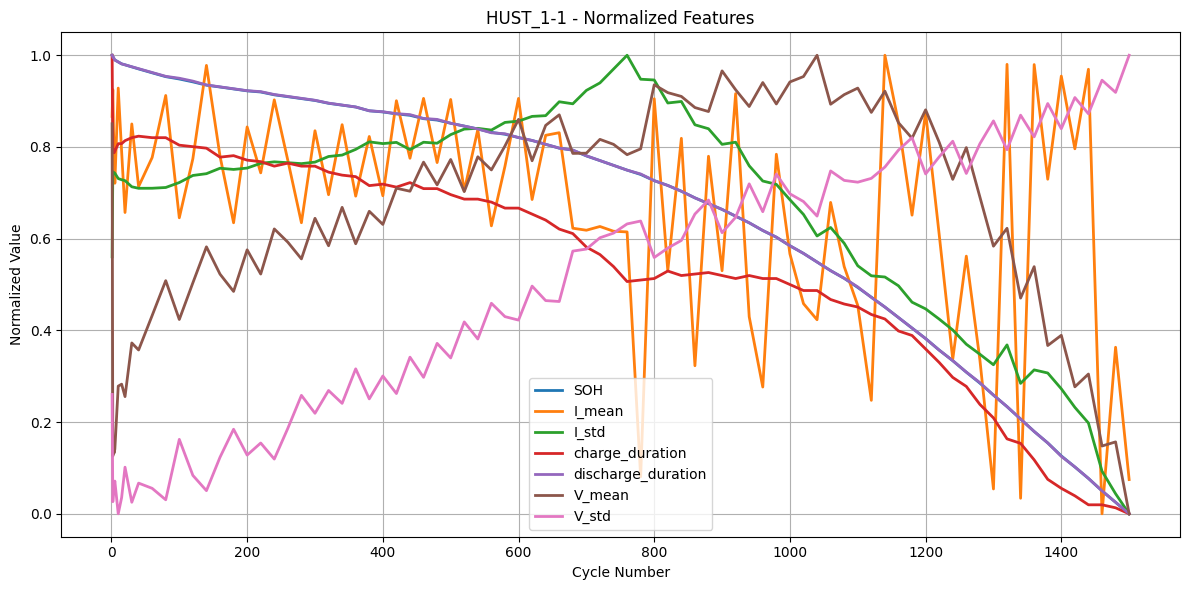

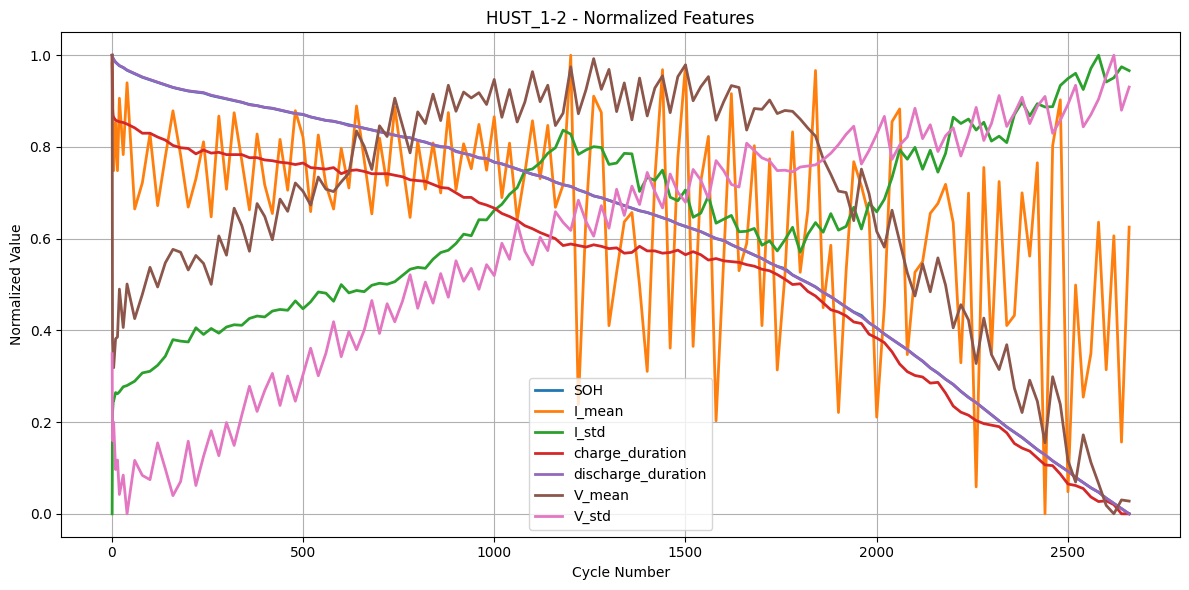

In [6]:
feature_cols = [
    "SOH",
    "I_mean",
    "I_std",
    "charge_duration",
    "discharge_duration",
    "V_mean",
    "V_std"
]

for i, (cell_id, group) in enumerate(feature_df.groupby("cell_id")):

    if i >= 2:  # Nur die ersten 5 Zellen
        break

    plt.figure(figsize=(12, 6))

    for feature in feature_cols:

        values = group[feature].values

        # Min-Max-Normierung
        vmin = np.nanmin(values)
        vmax = np.nanmax(values)

        if vmax > vmin:
            values_norm = (values - vmin) / (vmax - vmin)
        else:
            values_norm = np.zeros_like(values)

        plt.plot(
            group["cycle_number"],
            values_norm,
            label=feature,
            linewidth=2
        )

    plt.title(f"{cell_id} - Normalized Features")
    plt.xlabel("Cycle Number")
    plt.ylabel("Normalized Value")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()



In [7]:
# DTW-Feature: Dynamische Zeitverschiebung der Stromkurven
from dtaidistance import dtw

dtw_features = []

for data in datasets:

    cycles = data["cycle_data"]


    ref = np.array(cycles[1]["current_in_A"], dtype=np.float32)
    ref = (ref - np.mean(ref)) / (np.std(ref) + 1e-8)

    for cycle in cycles:

        x = np.array(cycle["current_in_A"], dtype=np.float32)
        x = (x - np.mean(x)) / (np.std(x) + 1e-8)

        dist = dtw.distance(ref, x)

        dtw_features.append({
            "cell_id": data["cell_id"],
            "cycle_number": cycle["cycle_number"],
            "DTW_I": dist
        })

dtw_df = pd.DataFrame(dtw_features)

In [8]:
feature_df = feature_df.merge(
    dtw_df,
    on=["cell_id", "cycle_number"],
    how="left"
)

In [9]:
from dtaidistance import dtw
import numpy as np
import pandas as pd

dtw_v_features = []

for data in datasets:

    cycles = data["cycle_data"]


    ref_v = np.array(cycles[1]["voltage_in_V"], dtype=np.float32)
    ref_v = (ref_v - np.mean(ref_v)) / (np.std(ref_v) + 1e-8)

    for cycle in cycles:

        v = np.array(cycle["voltage_in_V"], dtype=np.float32)
        v = (v - np.mean(v)) / (np.std(v) + 1e-8)

        dist_v = dtw.distance(ref_v, v)

        dtw_v_features.append({
            "cell_id": data["cell_id"],
            "cycle_number": cycle["cycle_number"],
            "DTW_V": dist_v
        })

dtw_v_df = pd.DataFrame(dtw_v_features)

In [10]:
feature_df = feature_df.merge(
    dtw_v_df,
    on=["cell_id", "cycle_number"],
    how="left"
)

In [11]:
# Speicherung der berechneten Features als Pickle-Datei

filename = f"processed_battery_features_{Dataset}.pkl"

with open(filename, "wb") as f:
    pickle.dump(feature_df, f)